In [1]:
import pandas as pd, numpy as np, seaborn as sns, matplotlib.pyplot as plt
import glob, os, sys

from data.movie import Frames, Audio, People # Measures
from data.spikes import Rates # LFP, BOLD
from data.behavior import Gaze, Suspense # Suspense, Valence, Arousal

from tqdm import tqdm

### load

In [2]:
FRs, suspense = Rates(), Suspense()

FRs, suspense = FRs.rescale(1), suspense.rescale(1)
suspense = np.mean(suspense, axis=1)
FRs.shape, suspense.shape

((479, 1457), (479,))

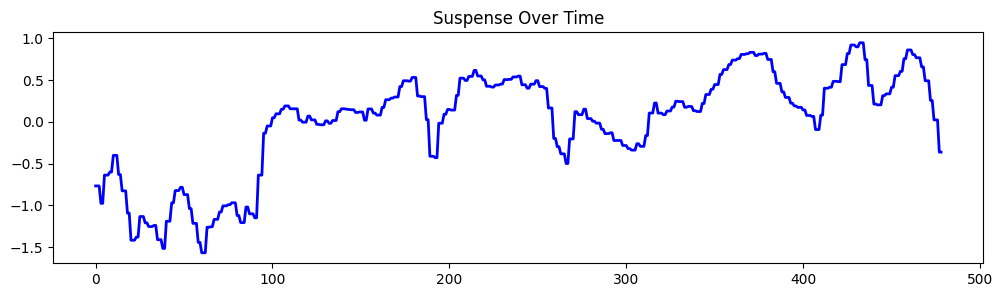

In [3]:
plt.figure(figsize=(12, 3))
plt.title('Suspense Over Time')
plt.plot(suspense, color='blue', linewidth=2)
plt.show()

### decoding

In [4]:
threshold = np.percentile(suspense, 50)

high_mask, low_mask = suspense > threshold,  suspense <= threshold
high_times, low_times = np.where(high_mask)[0], np.where(low_mask)[0]


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier

# Setup: high susp = 1, low = 0
X = np.concatenate([FRs.iloc[high_times], FRs.iloc[low_times]])          # (n_high + n_low, 1457)
y = np.concatenate([np.ones(len(high_times)), np.zeros(len(low_times))])  # (n_high + n_low, )

# Simple decoder
clf = LogisticRegression(max_iter=1000)
scores = cross_val_score(clf, X, y, cv=5)
print(f'Decoding accuracy: {np.mean(scores):.3f} ± {np.std(scores):.3f}')

# XGBoost decoder
clf = XGBClassifier(eval_metric='logloss')
scores = cross_val_score(clf, X, y, cv=5)
print(f'Decoding accuracy: {scores.mean():.3f} ± {scores.std():.3f}')


Decoding accuracy: 0.497 ± 0.103
Decoding accuracy: 0.570 ± 0.092


### audio